In [1]:
# ==========================================================
# STEP 1: Load datasets
# ==========================================================

import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

df_sample = pd.read_csv(
    '/content/drive/MyDrive/ LLM application for Maintenance Decision Making/Data/sample_df_500.csv'
)

df_2017 = pd.read_csv(
    '/content/drive/MyDrive/ LLM application for Maintenance Decision Making/Data/row-matching calculation/2017.csv'
)

# Clean column names
df_sample.columns = df_sample.columns.str.strip()
df_2017.columns = df_2017.columns.str.strip()

print(df_sample.shape)
print(df_2017.shape)

Mounted at /content/drive
(500, 21)
(23554, 58)


In [2]:
df_sample.columns

Index(['AADT', 'AADT Single Unit', 'AADT Combination', 'Future AADT',
       'International Roughness Index', 'Thickness of Rigid Pavements',
       'Thickness of Flexible Pavements', 'Thickness of Base Pavements',
       'Functional System', 'Urban Type', 'Surface Type', 'Base Type',
       'Rutting', 'Cracking Percent', 'Faulting', 'Relative Humidity',
       'Freezing Index', 'Average Temperature', 'Precipitation', 'Age',
       'Maintenance Intervention'],
      dtype='object')

In [3]:
df_2017.columns

Index(['AADT_mean', 'AADT_Single_Unit_mean', 'AADT_Combination_mean',
       'Dir_Factor_mean', 'Future_AADT_mean', 'IRI_mean', 'Rutting_mean',
       'Cracking_Percent_mean', 'Thickness_Rigid_mean',
       'Thickness_Flexible_mean', 'Base_Thickness_mean', 'Lane_Width_mean',
       'Last_Overlay_Thickness_mean', 'F_System_mode', 'Urban_Code_mode',
       'Through_Lanes_mode', 'Surface_Type_mode', 'Base_Type_mode',
       'County_Code_mode', 'State_Code_mode', 'Year_Last_Improv_mode',
       'Year_Last_Construction_mode', 'RHU_AV', 'RHU_AV_MN', 'RHU_AV_MX',
       'ALBEDO_AVG', 'CLD_CVR_AV', 'EMISSIVITY', 'EMIS_AVG', 'PER_SUN_AV',
       'SW_SF_AVG', 'SW_SF_STDV', 'SW_SURFACE', 'SW_TOA', 'DAYS_A_32C',
       'DAYS_BL_0C', 'FRZ_IDX', 'FRZ_THAW', 'SOIL_TL1AV', 'SOIL_TL2AV',
       'TEMP_AVG', 'TEMP_MAX', 'TEMP_MIN', 'AVG_WND_VEL_AV', 'AVG_WND_VEL_MX',
       'PRECIPITATION', 'EVAPORATION', 'hzdepb_r_mean', 'sieveno4_r_mean',
       'sieveno10_r_mean', 'sieveno40_r_mean', 'sieveno200_r_mea

In [4]:
# ==========================================================
# STEP 2: Match rows using 7 engineering variables
# ==========================================================
#
# Variables:
# AADT
# AADT Single Unit
# AADT Combination
# Future AADT
# IRI
# Rutting
# Cracking Percent
#
# This successfully matched 482 of 500 rows
# ==========================================================

county_list = []
state_list = []

for _, row in df_sample.iterrows():

    matches = df_2017[
        (df_2017['AADT_mean'].round(4) == round(row['AADT'], 4)) &
        (df_2017['AADT_Single_Unit_mean'].round(4) == round(row['AADT Single Unit'], 4)) &
        (df_2017['AADT_Combination_mean'].round(4) == round(row['AADT Combination'], 4)) &
        (df_2017['Future_AADT_mean'].round(4) == round(row['Future AADT'], 4)) &
        (df_2017['IRI_mean'].round(4) == round(row['International Roughness Index'], 4)) &
        (df_2017['Rutting_mean'].round(4) == round(row['Rutting'], 4)) &
        (df_2017['Cracking_Percent_mean'].round(4) == round(row['Cracking Percent'], 4))
    ]

    if len(matches) > 0:
        county_list.append(matches.iloc[0]['County_Code_mode'])
        state_list.append(matches.iloc[0]['State_Code_mode'])
    else:
        county_list.append(None)
        state_list.append(None)

# Store matched FIPS codes
df_sample['County_Code_mode'] = county_list
df_sample['State_Code_mode'] = state_list

print("Matched rows:", df_sample['County_Code_mode'].notna().sum())
print("Missing rows:", df_sample['County_Code_mode'].isna().sum())

Matched rows: 482
Missing rows: 18


In [5]:
# ==========================================================
# STEP 3: Extract unmatched rows
# ==========================================================

df_unmatched = df_sample[
    df_sample['County_Code_mode'].isna()
].copy()

print(df_unmatched.shape)

(18, 23)


In [6]:
## Find out after which colums you cannot find match
row = df_unmatched.iloc[0]

m1 = df_2017[df_2017['AADT_mean'] == row['AADT']]
print("AADT:", m1.shape)

m2 = m1[m1['IRI_mean'] == row['International Roughness Index']]
print("AADT + IRI:", m2.shape)

m3 = m2[m2['Rutting_mean'] == row['Rutting']]
print("AADT + IRI + Rutting:", m3.shape)

m4 = m3[m3['Cracking_Percent_mean'] == row['Cracking Percent']]
print("AADT + IRI + Rutting + Cracking:", m4.shape)

m5 = m4[m4['AADT_Single_Unit_mean'] == row['AADT Single Unit']]
print("+ AADT Single Unit:", m5.shape)

m6 = m5[m5['AADT_Combination_mean'] == row['AADT Combination']]
print("+ AADT Combination:", m6.shape)

m7 = m6[m6['Future_AADT_mean'] == row['Future AADT']]
print("+ Future AADT:", m7.shape)

AADT: (2, 58)
AADT + IRI: (1, 58)
AADT + IRI + Rutting: (0, 58)
AADT + IRI + Rutting + Cracking: (0, 58)
+ AADT Single Unit: (0, 58)
+ AADT Combination: (0, 58)
+ Future AADT: (0, 58)


In [7]:
# ==========================================================
# STEP 4: Check duplicate AADT values in unmatched rows
# ==========================================================

aadt_counts = df_unmatched['AADT'].value_counts()

print(aadt_counts[aadt_counts > 1])

Series([], Name: count, dtype: int64)


In [8]:
# ==========================================================
# STEP 5: Search unmatched rows using AADT only
# ==========================================================
#
# Since AADT values are unique within the unmatched set,
# use AADT as the fallback matching key.
# ==========================================================

for idx, row in df_unmatched.iterrows():

    matches = df_2017[
        df_2017['AADT_mean'] == row['AADT']
    ]

    if len(matches) > 0:
        df_sample.loc[idx, 'County_Code_mode'] = matches.iloc[0]['County_Code_mode']
        df_sample.loc[idx, 'State_Code_mode'] = matches.iloc[0]['State_Code_mode']

In [9]:
# ==========================================================
# STEP 6: Verify final matching results
# ==========================================================

print("Final matched rows:",
      df_sample['County_Code_mode'].notna().sum())

print("Final missing rows:",
      df_sample['County_Code_mode'].isna().sum())

Final matched rows: 500
Final missing rows: 0


In [10]:
df_sample

,AADT,AADT Single Unit,AADT Combination,Future AADT,International Roughness Index,Thickness of Rigid Pavements,Thickness of Flexible Pavements,Thickness of Base Pavements,Functional System,Urban Type,...,Cracking Percent,Faulting,Relative Humidity,Freezing Index,Average Temperature,Precipitation,Age,Maintenance Intervention,County_Code_mode,State_Code_mode
0,71446.0,4259.0,7445.0,85878.0,71.5,0.0,10.5,15.0,Interstate,rural,...,0.0,0.0,75.5,224.4,11.6,1318.4,58,Thin Overlay,21.0,24.0
1,8300.0,130.0,40.0,10300.0,108.0,0.0,12.0,17.0,Minor Arterial,urban,...,2.0,0.0,78.2,216.0,10.4,1435.3,26,No Maintenance,11.0,9.0
2,750.0,43.0,7.0,1000.0,242.5,0.0,3.0,12.0,Major Collector,urban,...,0.0,0.0,77.6,254.6,10.4,1398.8,9,Thin Overlay,7.0,9.0
3,4513.0,50.0,14.0,5032.0,236.0,0.0,10.0,6.0,Major Collector,urban,...,5.5,0.0,75.3,227.2,12.2,1246.0,67,No Maintenance,61.0,39.0
4,8875.0,502.0,28.0,13188.0,116.3,0.0,6.5,12.0,Minor Arterial,urban,...,0.3,0.0,84.0,25.0,9.4,1628.8,43,Thin Overlay,53.0,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,24743.0,1039.0,4478.0,26820.0,58.0,0.0,9.0,28.0,Interstate,rural,...,0.0,0.0,81.2,622.0,7.4,1444.6,16,Thin Overlay,23.0,23.0
496,4200.0,874.0,986.0,6461.0,99.9,0.0,2.0,8.0,Minor Arterial,rural,...,8.0,0.0,76.2,0.0,22.1,1129.0,9,Thin Overlay,105.0,12.0
497,28700.0,1318.0,754.0,28800.0,120.0,7.0,1.0,10.0,Principal Arterial – Other,urban,...,2.0,0.0,78.2,130.1,11.5,1379.0,8,No Maintenance,1.0,9.0
498,63307.0,3119.0,7145.0,76728.0,72.0,0.0,9.5,18.0,Interstate,urban,...,0.0,0.0,77.7,393.9,9.3,1382.1,59,Thin Overlay,79.0,42.0


In [11]:
df_sample['State_Code_mode'].unique()

array([24.,  9., 39., 53., 48., 42., 37., 33., 12., 41., 23., 17., 44.,
       30., 32., 38., 51., 34., 45., 27., 26.,  5., 20., 46., 56., 55.])

In [12]:
df_sample.to_csv('df_500_State_code.csv')

## Check new sample data and 2017 data row matched for FIPS code

In [13]:
# 2. Rename sample columns to match 2017 columns
# =========================
column_map = {
    'AADT': 'AADT_mean',
    'AADT Single Unit': 'AADT_Single_Unit_mean',
    'AADT Combination': 'AADT_Combination_mean',
    'Future AADT': 'Future_AADT_mean',
    'International Roughness Index': 'IRI_mean',
    'Thickness of Rigid Pavements': 'Thickness_Rigid_mean',
    'Thickness of Flexible Pavements': 'Thickness_Flexible_mean',
    'Thickness of Base Pavements': 'Base_Thickness_mean',
    'Functional System': 'F_System_mode',
    'Urban Type': 'Urban_Code_mode',
    'Surface Type': 'Surface_Type_mode',
    'Base Type': 'Base_Type_mode',
    'Rutting': 'Rutting_mean',
    'Cracking Percent': 'Cracking_Percent_mean',
    'Relative Humidity': 'RHU_AV',
    'Freezing Index': 'FRZ_IDX',
    'Average Temperature': 'TEMP_AVG',
    'Precipitation': 'PRECIPITATION'
}

df_sample = df_sample.rename(columns=column_map)

In [14]:
import pandas as pd

# =============================================================================
# CHECK: Every row in df_sample exists in df_2017
# df_sample already includes County_Code_mode and State_Code_mode
# =============================================================================

# Use all columns from df_sample for matching
check_cols = df_sample.columns.tolist()

# Make sure df_2017 has all these columns
missing_cols = [col for col in check_cols if col not in df_2017.columns]

if missing_cols:
    print("❌ These columns are missing in df_2017:")
    print(missing_cols)

else:
    # Match df_sample rows against df_2017 using all df_sample columns
    validation = df_sample.merge(
        df_2017[check_cols],
        how="left",
        on=check_cols,
        indicator=True
    )

    total_sample_rows = len(df_sample)
    matched_rows = (validation["_merge"] == "both").sum()
    unmatched_rows = (validation["_merge"] != "both").sum()

    print("=" * 80)
    print("ROW MATCH CHECK: df_sample vs df_2017")
    print(f"Total rows in df_sample : {total_sample_rows}")
    print(f"Rows matched in df_2017 : {matched_rows}")
    print(f"Rows not matched        : {unmatched_rows}")

    if unmatched_rows == 0:
        print("✅ SUCCESS: All df_sample rows fully match rows in df_2017.")
    else:
        print("❌ Some df_sample rows do not fully match df_2017.")

        unmatched_df = (
            validation[validation["_merge"] != "both"]
            .drop(columns="_merge")
        )

        display(unmatched_df.head(20))

❌ These columns are missing in df_2017:
['Faulting', 'Age', 'Maintenance Intervention']


In [15]:
df_500_State_code = df_sample.rename(columns={
    'AADT_mean_x': 'AADT',
    'AADT_Single_Unit_mean_x': 'AADT Single Unit',
    'AADT_Combination_mean_x' : 'AADT Combination',
    'Future_AADT_mean_x' : 'Future AADT',
    'IRI_mean_x' : "International Roughness Index",
    'Thickness_Rigid_mean_x': 'Thickness of Rigid Pavements',
    'Thickness_Flexible_mean_x' : 'Thickness of Flexible Pavements',
    'Base_Thickness_mean_x' : 'Thickness of Base Pavements',
    'F_System_mode' : 'Functional System',
    'Urban_Type' : 'Urban Type',
    'Surface_Type_mode' : 'Surface Type',
    'Base_Type_mode_x': 'Base Type',
    'Rutting_mean_x': 'Rutting',
    'Cracking_Percent_mean_x' : 'Cracking Percent',
    'Faulting_mean_x' : 'Faulting',
    'RHU_AV_x' : 'Relative Humidity',
    'FRZ_IDX_x' : 'Freezing Index',
    'TEMP_AVG_x' : 'Average Temperature',
    'PRECIPITATION_x' : 'Precipitation',
    'Age_x' : 'Age'

})

In [16]:
df_500_State_code.columns

Index(['AADT_mean', 'AADT_Single_Unit_mean', 'AADT_Combination_mean',
       'Future_AADT_mean', 'IRI_mean', 'Thickness_Rigid_mean',
       'Thickness_Flexible_mean', 'Base_Thickness_mean', 'Functional System',
       'Urban_Code_mode', 'Surface Type', 'Base_Type_mode', 'Rutting_mean',
       'Cracking_Percent_mean', 'Faulting', 'RHU_AV', 'FRZ_IDX', 'TEMP_AVG',
       'PRECIPITATION', 'Age', 'Maintenance Intervention', 'County_Code_mode',
       'State_Code_mode'],
      dtype='object')

In [17]:
df_500_State_code.dtypes

,0
AADT_mean,float64
AADT_Single_Unit_mean,float64
AADT_Combination_mean,float64
Future_AADT_mean,float64
IRI_mean,float64
Thickness_Rigid_mean,float64
Thickness_Flexible_mean,float64
Base_Thickness_mean,float64
Functional System,object
Urban_Code_mode,object


In [18]:
df_sample_500 = pd.read_csv(
    '/content/drive/MyDrive/ LLM application for Maintenance Decision Making/Data/sample_df_500.csv'
)
df_sample_500.columns

Index(['AADT', 'AADT Single Unit', 'AADT Combination', 'Future AADT',
       'International Roughness Index', 'Thickness of Rigid Pavements',
       'Thickness of Flexible Pavements', 'Thickness of Base Pavements',
       'Functional System', 'Urban Type', 'Surface Type', 'Base Type',
       'Rutting', 'Cracking Percent', 'Faulting', 'Relative Humidity',
       'Freezing Index', 'Average Temperature', 'Precipitation', 'Age',
       'Maintenance Intervention'],
      dtype='object')

In [19]:
df_sample_500.dtypes

,0
AADT,float64
AADT Single Unit,float64
AADT Combination,float64
Future AADT,float64
International Roughness Index,float64
Thickness of Rigid Pavements,float64
Thickness of Flexible Pavements,float64
Thickness of Base Pavements,float64
Functional System,object
Urban Type,object


In [20]:
df_sample_human_labeled = pd.read_csv(
    '/content/drive/MyDrive/ LLM application for Maintenance Decision Making/Outputs/Human Review/individual_maintenance_reasoning_500_output_script_05_10_2026_human_labeling_tamim.csv'
)
df_sample_human_labeled.columns

Index(['AADT', 'AADT Single Unit', 'AADT Combination', 'Future AADT',
       'International Roughness Index', 'Thickness of Rigid Pavements',
       'Thickness of Flexible Pavements', 'Thickness of Base Pavements',
       'Functional System', 'Urban Type', 'Surface Type', 'Base Type',
       'Rutting', 'Cracking Percent', 'Faulting', 'Relative Humidity',
       'Freezing Index', 'Average Temperature', 'Precipitation', 'Age',
       'Maintenance Intervention', 'Tamim Review',
       'Predicted_Maintenance_Type', 'Reasoning', 'Raw_Response'],
      dtype='object')

In [21]:
import pandas as pd
import numpy as np

# =============================================================================
# CHECK COMMON COLUMNS BETWEEN SAMPLE AND HUMAN-LABELED DATASETS
# Goal:
# 1. Same common columns
# 2. Same row count
# 3. Same row order / index
# 4. Same values
# 5. Same data types
# =============================================================================

# Use df_sample_500 column order as the reference
common_cols = [
    col for col in df_sample_500.columns
    if col in df_sample_human_labeled.columns
]

print("=" * 80)
print(f"Number of common columns: {len(common_cols)}")
print(common_cols)

# =============================================================================
# STEP 1: Compare shapes
# =============================================================================

sample_common = df_sample_500[common_cols]
human_common = df_sample_human_labeled[common_cols]

print("\n" + "=" * 80)
print("Shape Check")
print("df_sample_500          :", sample_common.shape)
print("df_sample_human_labeled:", human_common.shape)

same_shape = sample_common.shape == human_common.shape
print("Same shape:", same_shape)

# =============================================================================
# STEP 2: Compare index / row order
# =============================================================================

print("\n" + "=" * 80)
print("Index / Row Order Check")

same_index = sample_common.index.equals(human_common.index)
print("Same index / row order:", same_index)

# =============================================================================
# STEP 3: Compare column order
# =============================================================================

print("\n" + "=" * 80)
print("Column Order Check")

same_column_order = list(sample_common.columns) == list(human_common.columns)
print("Same column order:", same_column_order)

# =============================================================================
# STEP 4: Compare data types
# =============================================================================

print("\n" + "=" * 80)
print("Data Type Check")

dtype_compare = pd.DataFrame({
    "sample_dtype": sample_common.dtypes.astype(str),
    "human_dtype": human_common.dtypes.astype(str),
})

dtype_compare["same_dtype"] = (
    dtype_compare["sample_dtype"] == dtype_compare["human_dtype"]
)

display(dtype_compare)

same_dtypes = dtype_compare["same_dtype"].all()
print("Same data types:", same_dtypes)

# Show only mismatched dtype columns
if not same_dtypes:
    print("\nColumns with different data types:")
    display(dtype_compare[dtype_compare["same_dtype"] == False])

# =============================================================================
# STEP 5: Compare actual values only
# This ignores dtype differences such as int64 vs float64
# =============================================================================

print("\n" + "=" * 80)
print("Value Check")

same_values = sample_common.compare(human_common).empty

print("Same values:", same_values)

# If values are different, show exact differences
if not same_values:
    print("\nCell-level value differences:")
    display(sample_common.compare(human_common).head(50))

# =============================================================================
# STEP 6: Strict equality check
# This requires same values AND same dtypes
# =============================================================================

print("\n" + "=" * 80)
print("Strict Equality Check")

strict_equal = sample_common.equals(human_common)

print("Strictly equal using .equals():", strict_equal)

# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 80)
print("FINAL SUMMARY")

if same_shape and same_index and same_column_order and same_values and same_dtypes:
    print("✅ SUCCESS: df_sample_500 and df_sample_human_labeled match perfectly.")
    print("   - Same row count")
    print("   - Same row order/index")
    print("   - Same column order")
    print("   - Same values")
    print("   - Same data types")
elif same_shape and same_index and same_column_order and same_values and not same_dtypes:
    print("⚠️ VALUES MATCH, BUT DATA TYPES DIFFER.")
    print("   - Same row count")
    print("   - Same row order/index")
    print("   - Same values")
    print("   - But one or more common columns have different dtypes.")
else:
    print("❌ MISMATCH FOUND.")
    print("   Review the checks above.")

Number of common columns: 21
['AADT', 'AADT Single Unit', 'AADT Combination', 'Future AADT', 'International Roughness Index', 'Thickness of Rigid Pavements', 'Thickness of Flexible Pavements', 'Thickness of Base Pavements', 'Functional System', 'Urban Type', 'Surface Type', 'Base Type', 'Rutting', 'Cracking Percent', 'Faulting', 'Relative Humidity', 'Freezing Index', 'Average Temperature', 'Precipitation', 'Age', 'Maintenance Intervention']

Shape Check
df_sample_500          : (500, 21)
df_sample_human_labeled: (500, 21)
Same shape: True

Index / Row Order Check
Same index / row order: True

Column Order Check
Same column order: True

Data Type Check


,sample_dtype,human_dtype,same_dtype
AADT,float64,int64,False
AADT Single Unit,float64,float64,True
AADT Combination,float64,int64,False
Future AADT,float64,int64,False
International Roughness Index,float64,float64,True
Thickness of Rigid Pavements,float64,float64,True
Thickness of Flexible Pavements,float64,float64,True
Thickness of Base Pavements,float64,float64,True
Functional System,object,object,True
Urban Type,object,object,True


Same data types: False

Columns with different data types:


,sample_dtype,human_dtype,same_dtype
AADT,float64,int64,False
AADT Combination,float64,int64,False
Future AADT,float64,int64,False



Value Check
Same values: True

Strict Equality Check
Strictly equal using .equals(): False

FINAL SUMMARY
⚠️ VALUES MATCH, BUT DATA TYPES DIFFER.
   - Same row count
   - Same row order/index
   - Same values
   - But one or more common columns have different dtypes.


In [22]:
# Columns with dtype mismatch
cols_to_fix = ['AADT', 'AADT Combination', 'Future AADT']

# Convert human-labeled dataset columns from int64 to float64
df_sample_human_labeled[cols_to_fix] = df_sample_human_labeled[cols_to_fix].astype(float)

# Recheck dtypes
print(df_sample_500[cols_to_fix].dtypes)
print(df_sample_human_labeled[cols_to_fix].dtypes)

# Recheck equality for all common columns
same_after_dtype_fix = df_sample_500[common_cols].equals(
    df_sample_human_labeled[common_cols]
)

print("Same after dtype fix:", same_after_dtype_fix)

AADT                float64
AADT Combination    float64
Future AADT         float64
dtype: object
AADT                float64
AADT Combination    float64
Future AADT         float64
dtype: object
Same after dtype fix: True


In [23]:
# After dtype conversion

common_cols = df_sample_500.columns

all_values_match = (
    df_sample_500[common_cols]
    .compare(df_sample_human_labeled[common_cols])
    .empty
)

print("All values match:", all_values_match)

All values match: True


In [24]:
# pip install plotly pandas

import pandas as pd
import plotly.express as px

selected_codes = [
    24, 9, 39, 53, 48, 42, 37, 33, 12, 41,
    23, 17, 44, 30, 32, 38, 51, 34, 45, 27,
    26, 5, 20, 46, 56, 55
]

# FIPS/state code to abbreviation
state_fips = {
    1:"AL", 2:"AK", 4:"AZ", 5:"AR", 6:"CA", 8:"CO", 9:"CT", 10:"DE",
    11:"DC", 12:"FL", 13:"GA", 15:"HI", 16:"ID", 17:"IL", 18:"IN",
    19:"IA", 20:"KS", 21:"KY", 22:"LA", 23:"ME", 24:"MD", 25:"MA",
    26:"MI", 27:"MN", 28:"MS", 29:"MO", 30:"MT", 31:"NE", 32:"NV",
    33:"NH", 34:"NJ", 35:"NM", 36:"NY", 37:"NC", 38:"ND", 39:"OH",
    40:"OK", 41:"OR", 42:"PA", 44:"RI", 45:"SC", 46:"SD", 47:"TN",
    48:"TX", 49:"UT", 50:"VT", 51:"VA", 53:"WA", 54:"WV", 55:"WI",
    56:"WY"
}

df_map = pd.DataFrame({
    "State_Code": selected_codes
})

df_map["State"] = df_map["State_Code"].map(state_fips)
df_map["Highlight"] = "Selected"

fig = px.choropleth(
    df_map,
    locations="State",
    locationmode="USA-states",
    color="Highlight",
    scope="usa",
    hover_name="State",
    color_discrete_map={"Selected": "green"}
)

fig.update_layout(
    title_text="Selected States in the Sample Dataset",
    title_x=0.5,
    geo=dict(
        lakecolor="white",
        bgcolor="white"
    ),
    showlegend=False
)

fig.show()

In [25]:
!pip install bokeh_sampledata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.5/475.5 kB 31.7 MB/s eta 0:00:00


| Code | State          | Abbrev |
| ---- | -------------- | ------ |
| 5    | Arkansas       | AR     |
| 9    | Connecticut    | CT     |
| 12   | Florida        | FL     |
| 17   | Illinois       | IL     |
| 20   | Kansas         | KS     |
| 23   | Maine          | ME     |
| 24   | Maryland       | MD     |
| 26   | Michigan       | MI     |
| 27   | Minnesota      | MN     |
| 30   | Montana        | MT     |
| 32   | Nevada         | NV     |
| 33   | New Hampshire  | NH     |
| 34   | New Jersey     | NJ     |
| 37   | North Carolina | NC     |
| 38   | North Dakota   | ND     |
| 39   | Ohio           | OH     |
| 41   | Oregon         | OR     |
| 42   | Pennsylvania   | PA     |
| 44   | Rhode Island   | RI     |
| 45   | South Carolina | SC     |
| 46   | South Dakota   | SD     |
| 48   | Texas          | TX     |
| 51   | Virginia       | VA     |
| 53   | Washington     | WA     |
| 55   | Wisconsin      | WI     |
| 56   | Wyoming        | WY     |


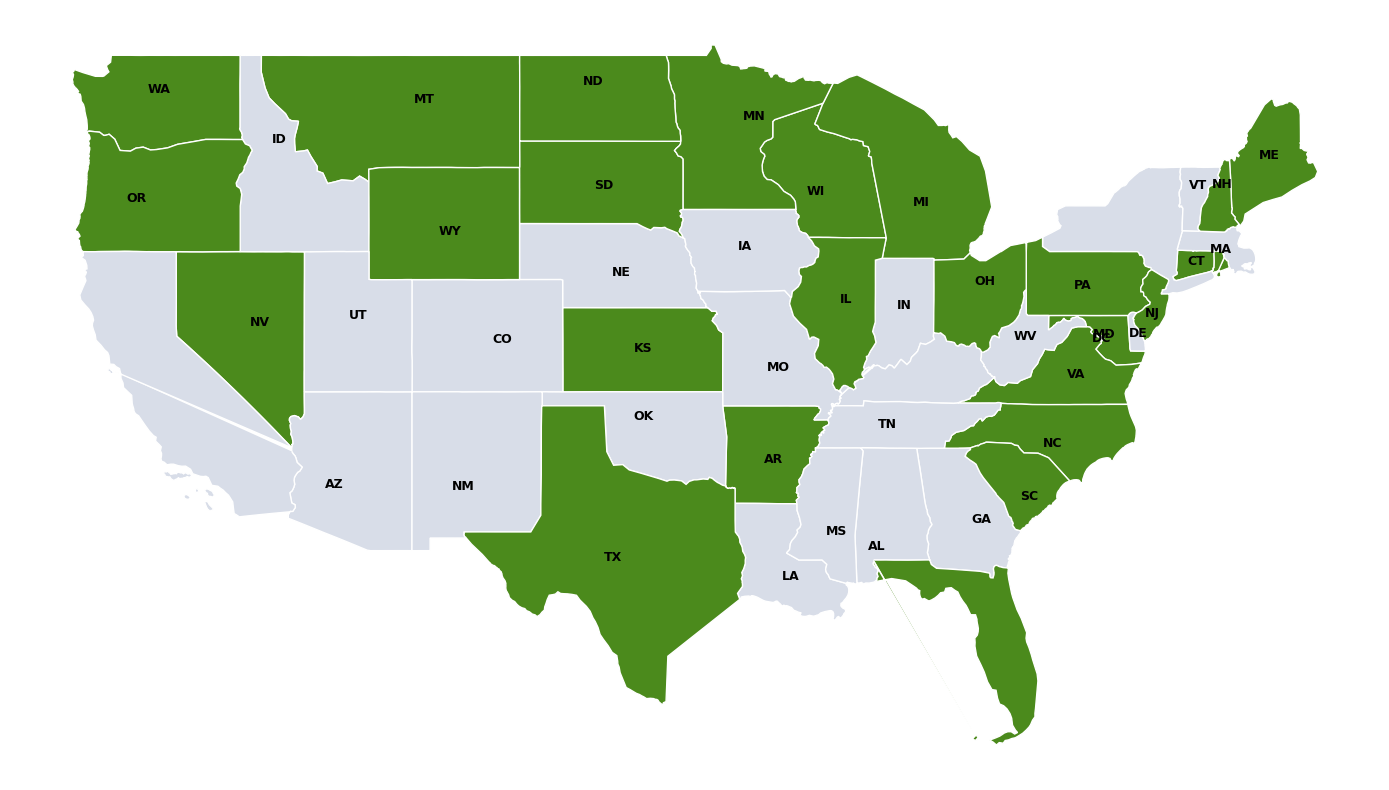

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from bokeh.sampledata.us_states import data as states

# Selected states
selected_states = [
    'MD','CT','OH','WA','TX','PA','NC','NH','FL','OR',
    'ME','IL','RI','MT','NV','ND','VA','NJ','SC','MN',
    'MI','AR','KS','SD','WY','WI'
]

fig, ax = plt.subplots(figsize=(14,8))

# Draw states
for code, state in states.items():

    # Skip Alaska, Hawaii, Puerto Rico if desired
    if code in ["AK", "HI", "PR"]:
        continue

    color = "#4B8A1C" if code in selected_states else "#D8DDE8"

    ax.fill(
        state["lons"],
        state["lats"],
        facecolor=color,
        edgecolor="white",
        linewidth=1
    )

    # Add abbreviation at state center
    x = sum(state["lons"]) / len(state["lons"])
    y = sum(state["lats"]) / len(state["lats"])

    ax.text(
        x, y,
        code,
        fontsize=9,
        fontweight='bold',
        ha='center',
        va='center',
        color='black'
    )

ax.axis("off")
plt.tight_layout()
plt.show()